# Probabilistic Regression & Ensemble Methods

Delivery-time prediction on the **Food_Time** dataset: classical regressors with uncertainty bands, ensemble models, and a controlled switch from regression to multi-class classification.

<a id="prep"></a>
## I. Постановка задачі та підготовка даних

Імпорт бібліотек:

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, accuracy_score, \
                            precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor, StackingRegressor, \
                             RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from xgboost import XGBRegressor, XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)

### 1. Завантаження датасету

In [2]:
data = pd.read_csv("Food_Time.csv")
data.head()

,Traffic_Level,ID,Delivery_person_ID,weather_description,Type_of_order,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET
0,High,70A2,CHENRES12DEL01,mist,Snack,scooter,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.45
1,High,95B4,RANCHIRES15DEL01,clear sky,Meal,scooter,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816.666.667
2,High,CDCD,DEHRES17DEL01,clear sky,Snack,motorcycle,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636.666.667
3,High,2784,PUNERES13DEL03,clear sky,Drinks,scooter,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.45
4,High,6F67,HYDRES14DEL01,overcast clouds,Snack,motorcycle,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248.333.333


In [3]:
data.shape, data.dtypes

((10000, 17),
 Traffic_Level                   object
 ID                              object
 Delivery_person_ID              object
 weather_description             object
 Type_of_order                   object
 Type_of_vehicle                 object
 Delivery_person_Age              int64
 Delivery_person_Ratings        float64
 Restaurant_latitude             object
 Restaurant_longitude            object
 Delivery_location_latitude      object
 Delivery_location_longitude     object
 temperature                    float64
 humidity                       float64
 precipitation                  float64
 Distance (km)                  float64
 TARGET                          object
 dtype: object)

In [4]:
data.isna().sum()

Traffic_Level                  915
ID                               0
Delivery_person_ID               0
weather_description              5
Type_of_order                    0
Type_of_vehicle                  0
Delivery_person_Age              0
Delivery_person_Ratings          0
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
temperature                      5
humidity                         5
precipitation                    5
Distance (km)                  920
TARGET                         541
dtype: int64

### 2. Розділення на тренувальні (80%) та тестові (20%) дані

In [5]:
target_col = "TARGET" if "TARGET" in data.columns else data.select_dtypes(include=[np.number]).columns[-1]
X = data.drop(columns=target_col)
drop_cols = [c for c in ["ID", "Delivery_person_ID"] if c in X.columns]
for col in ["Restaurant_latitude", "Restaurant_longitude", "Delivery_location_latitude", "Delivery_location_longitude"]:
    if col in X.columns and X[col].dtype == object:
        drop_cols.append(col)
if drop_cols:
    X = X.drop(columns=drop_cols)
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((8000, 10), (2000, 10))

### 3. Попереднє опрацювання даних
- Видалення/заміна пропусків
- Нормалізація числових ознак
- Перетворення категорійних змінних

In [6]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

transformers = []
if num_cols:
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    transformers.append(("num", num_pipe, num_cols))
if cat_cols:
    transformers.append(("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols))

preprocessor = ColumnTransformer(transformers=transformers)
preprocessor.set_output(transform="pandas")

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
print("Тренувальні дані після препроцесингу:")
X_train_transformed.head()

Тренувальні дані після препроцесингу:


,num__Delivery_person_Age,num__Delivery_person_Ratings,num__temperature,num__humidity,num__precipitation,num__Distance (km),cat__Traffic_Level_Low,cat__Traffic_Level_Moderate,cat__Traffic_Level_Very High,cat__Traffic_Level_Very Low,...,cat__weather_description_overcast clouds,cat__weather_description_scattered clouds,cat__weather_description_smoke,cat__weather_description_nan,cat__Type_of_order_Drinks,cat__Type_of_order_Meal,cat__Type_of_order_Snack,cat__Type_of_vehicle_electric_scooter,cat__Type_of_vehicle_motorcycle,cat__Type_of_vehicle_scooter
9254,0.254858,0.220682,0.649505,-1.746981,-0.216643,2.064876,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1561,1.131334,0.220682,0.898419,-0.072671,-0.216643,0.098255,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1670,0.079562,-1.980239,0.836191,0.442501,-0.216643,-0.030356,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6087,0.079562,-0.093736,-0.716559,0.056122,-0.216643,-0.834486,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6669,-0.621619,-1.351405,0.009440,-0.394654,-0.216643,-0.333778,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


<a id="regression"></a>
## II. Ймовірнісна регресія

### 1. Навчання регресійних моделей (не ансамблі)

In [7]:
models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("ElasticNet", ElasticNet()),
    ("Decision Tree", DecisionTreeRegressor(random_state=42)),
]

In [8]:
def get_regression_metrics(models, X_tr, y_tr, X_te, y_te):
    X_tr = np.ascontiguousarray(X_tr) if hasattr(X_tr, "values") else np.asarray(X_tr)
    X_te = np.ascontiguousarray(X_te) if hasattr(X_te, "values") else np.asarray(X_te)
    y_tr = pd.to_numeric(y_tr, errors="coerce").values.astype(np.float64)
    y_te = pd.to_numeric(y_te, errors="coerce").values.astype(np.float64)
    X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)
    y_mean = np.nanmean(y_tr)
    if np.isnan(y_mean):
        y_mean = 0.0
    y_tr = np.nan_to_num(y_tr, nan=y_mean)
    y_te = np.nan_to_num(y_te, nan=y_mean)
    scoring = {"MAE": "neg_mean_absolute_error", "R2": "r2", "RMSE": "neg_root_mean_squared_error"}
    results = []
    trained = {}
    for name, model in models:
        cv = cross_validate(model, X_tr, y_tr, cv=5, scoring=scoring, n_jobs=-1)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        results.append({
            "Model": name,
            "MAE": mean_absolute_error(y_te, y_pred),
            "RMSE": root_mean_squared_error(y_te, y_pred),
            "R2": r2_score(y_te, y_pred),
        })
        rmse_cv = -np.nanmean(cv["test_RMSE"])
        if np.isnan(rmse_cv) or rmse_cv <= 0:
            rmse_cv = root_mean_squared_error(y_te, y_pred)
        trained[name] = (model, rmse_cv)
    return pd.DataFrame(results), trained

In [9]:
results_df, trained_models = get_regression_metrics(models, X_train_transformed, y_train, X_test_transformed, y_test)
results_df = results_df.sort_values("MAE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,ElasticNet,5.026978,8.581542,0.211546
1,Lasso,5.243745,8.415577,0.241748
2,Linear Regression,5.467517,7.907533,0.330535
3,Ridge,5.469279,7.907633,0.330518
4,Decision Tree,6.073742,11.084692,-0.315507


### 2. Ймовірнісні межі (довірчі інтервали 95%)

Використовуємо підхід: Upper = ŷ + 1.96·RMSE_CV, Lower = ŷ - 1.96·RMSE_CV

In [10]:
def get_conf_int(y_hat, se, z=1.96):
    return (y_hat + z * se, y_hat - z * se)

def plot_ci(model_name, y_pred, se, y_actual, n_sample=80):
    ci_plus, ci_minus = get_conf_int(y_pred, se)
    y_act = np.asarray(pd.to_numeric(y_actual, errors="coerce"), dtype=np.float64).ravel()[:n_sample]
    y_act = np.nan_to_num(y_act, nan=np.nanmean(y_act))
    df = pd.DataFrame({"Actual": y_act, "Predicted": y_pred[:n_sample],
                       "Upper": ci_plus[:n_sample], "Lower": ci_minus[:n_sample]})
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(range(n_sample), df["Lower"], df["Upper"], alpha=0.2, color="gray", label="95% CI")
    ax.plot(df.index, df["Predicted"], "b-", lw=2, label="Prediction")
    ax.plot(df.index, df["Actual"], "ro", markersize=4, alpha=0.7, label="Actual")
    ax.set_title(f"95% Confidence Intervals: {model_name}")
    ax.legend()
    ax.set_xlabel("Test Sample Index")
    plt.tight_layout()
    plt.show()

c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but ElasticNet was fitted without feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


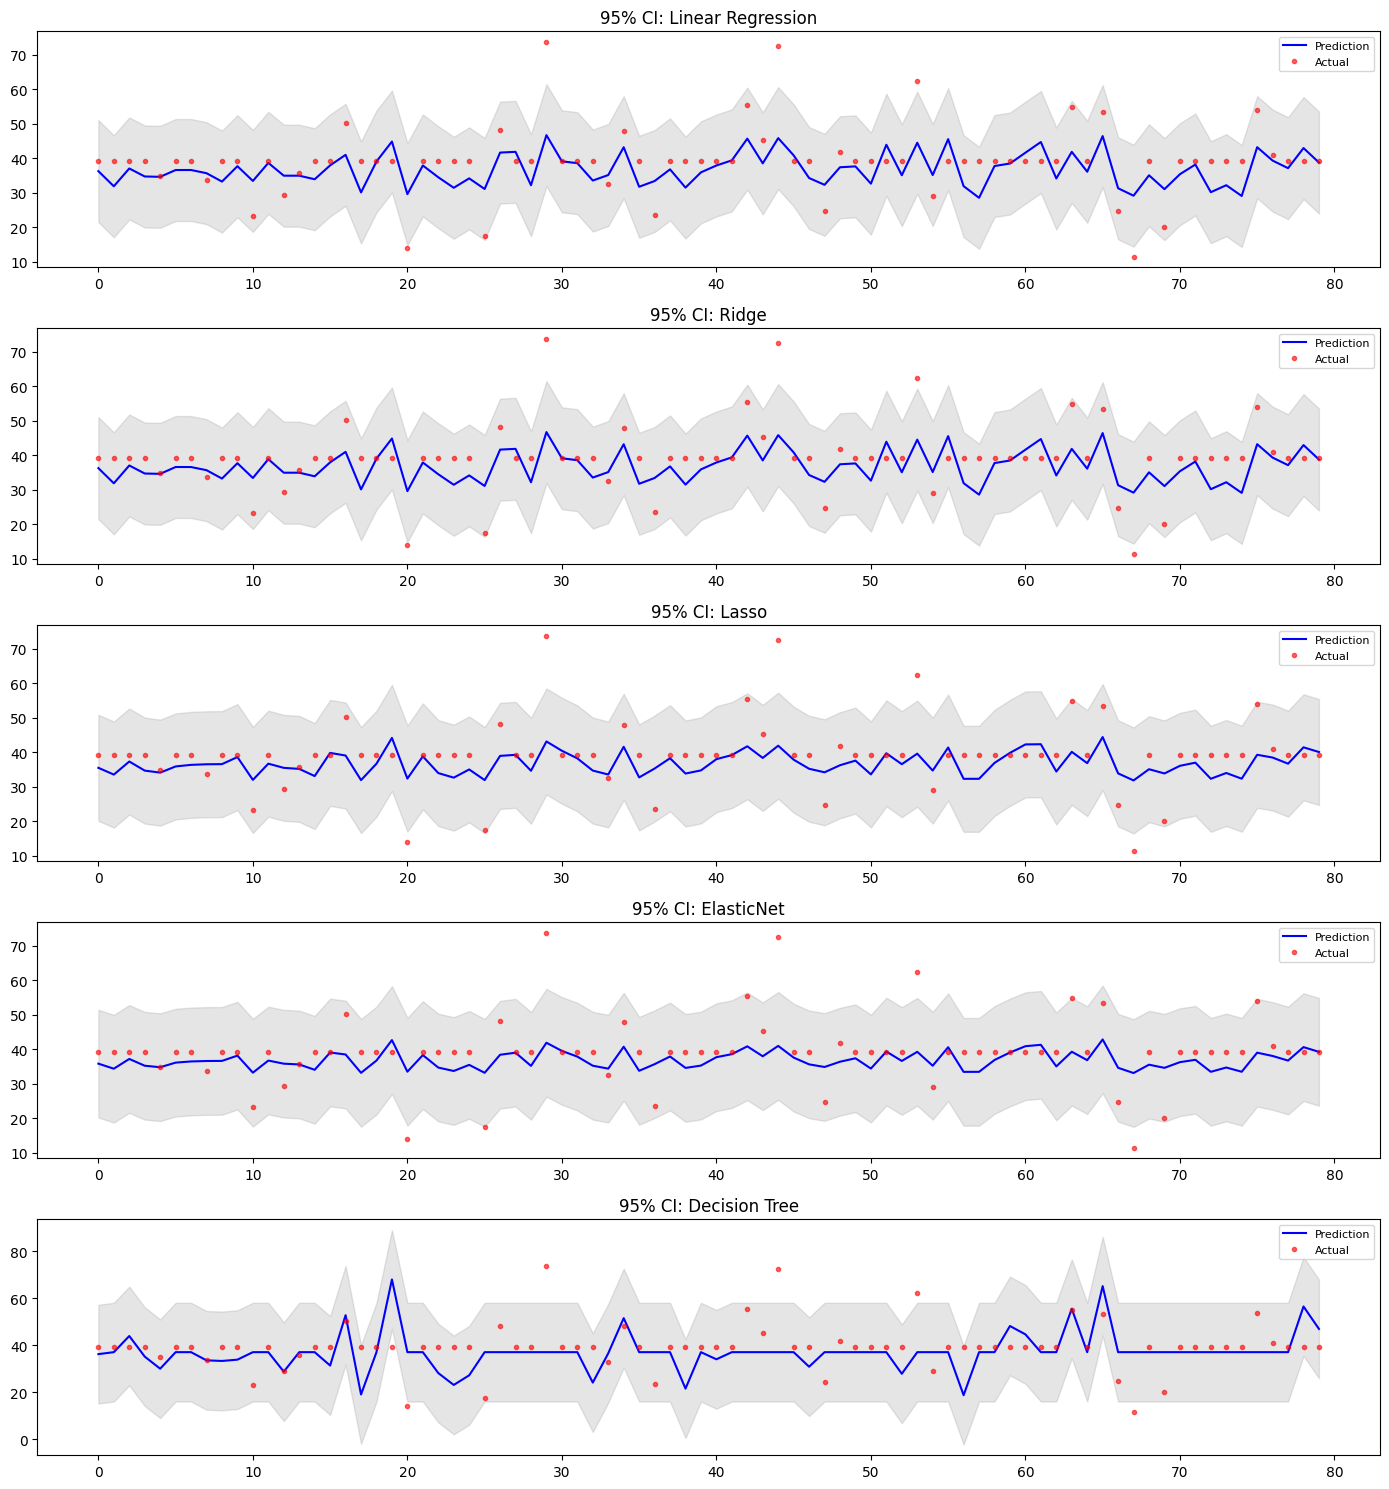

In [11]:
# Побудова графіків з довірчими інтервалами для кожної моделі
fig, axes = plt.subplots(len(models), 1, figsize=(14, 3 * len(models)))
if len(models) == 1:
    axes = [axes]
n_sample = min(80, len(y_test))
for ax, (name, _) in zip(axes, models):
    model, rmse_cv = trained_models[name]
    y_pred = model.predict(X_test_transformed)
    ci_plus, ci_minus = get_conf_int(y_pred, rmse_cv)
    ax.fill_between(range(n_sample), ci_minus[:n_sample], ci_plus[:n_sample], alpha=0.2, color="gray")
    ax.plot(range(n_sample), y_pred[:n_sample], "b-", lw=1.5, label="Prediction")
    y_act = np.asarray(pd.to_numeric(y_test, errors="coerce"), dtype=np.float64).ravel()[:n_sample]
    y_act = np.nan_to_num(y_act, nan=np.nanmean(y_act))
    ax.plot(range(n_sample), y_act, "ro", markersize=3, alpha=0.6, label="Actual")
    ax.set_title(f"95% CI: {name}")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

### 4. Оптимізація гіперпараметрів та повторна валідація

Оптимізуємо Decision Tree (базова модель з max_depth=None, min_samples_split=2). Простір пошуку включає ці значення.

In [12]:
tree = DecisionTreeRegressor(random_state=42)
param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["squared_error", "friedman_mse"],
}
grid_tree = GridSearchCV(tree, param_grid, cv=5, scoring="neg_mean_absolute_error", refit=True, n_jobs=-1, verbose=1)
X_tr = np.nan_to_num(np.asarray(X_train_transformed), nan=0.0)
y_tr = np.asarray(pd.to_numeric(y_train, errors="coerce"), dtype=np.float64)
y_tr = np.nan_to_num(y_tr, nan=np.nanmean(y_tr))
grid_tree.fit(X_tr, y_tr)
print("Best params:", grid_tree.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [13]:
# Оцінка до і після оптимізації
y_test_num = np.asarray(pd.to_numeric(y_test, errors="coerce"), dtype=np.float64)
y_test_num = np.nan_to_num(y_test_num, nan=np.nanmean(y_test_num))
y_pred_before = trained_models["Decision Tree"][0].predict(X_test_transformed)
y_pred_after = grid_tree.predict(X_test_transformed)
print("Decision Tree ДО оптимізації:  MAE={:.4f}, RMSE={:.4f}, R2={:.4f}".format(
    mean_absolute_error(y_test_num, y_pred_before), root_mean_squared_error(y_test_num, y_pred_before), r2_score(y_test_num, y_pred_before)))
print("Decision Tree ПІСЛЯ оптимізації: MAE={:.4f}, RMSE={:.4f}, R2={:.4f}".format(
    mean_absolute_error(y_test_num, y_pred_after), root_mean_squared_error(y_test_num, y_pred_after), r2_score(y_test_num, y_pred_after)))

Decision Tree ДО оптимізації:  MAE=6.6421, RMSE=11.1095, R2=-0.3255
Decision Tree ПІСЛЯ оптимізації: MAE=5.4714, RMSE=8.1878, R2=0.2800


c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


<a id="ensemble"></a>
## III. Ансамблеві методи

Bagging (Random Forest), Boosting (XGBoost, Gradient Boosting), Stacking

In [14]:
stacking_base = [
    ("rf", RandomForestRegressor(n_estimators=50, random_state=42)),
    ("knn", KNeighborsRegressor(n_neighbors=5)),
    ("gb", GradientBoostingRegressor(n_estimators=50, random_state=42)),
]
ensemble_models = [
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Bagging (KNN)", BaggingRegressor(estimator=KNeighborsRegressor(), n_estimators=50, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("XGBoost", XGBRegressor(n_estimators=100, random_state=42)),
    ("Stacking", StackingRegressor(estimators=stacking_base, final_estimator=Ridge())),
]

In [15]:
ensemble_results, ensemble_trained = get_regression_metrics(ensemble_models, X_train_transformed, y_train, X_test_transformed, y_test)
ensemble_results

,Model,MAE,RMSE,R2
0,Random Forest,5.518232,8.341152,0.255100
1,Bagging (KNN),5.358702,8.355759,0.252489
2,Gradient Boosting,5.409163,8.315613,0.259655
3,XGBoost,5.598269,8.929650,0.146282
4,Stacking,5.267971,8.104947,0.296691


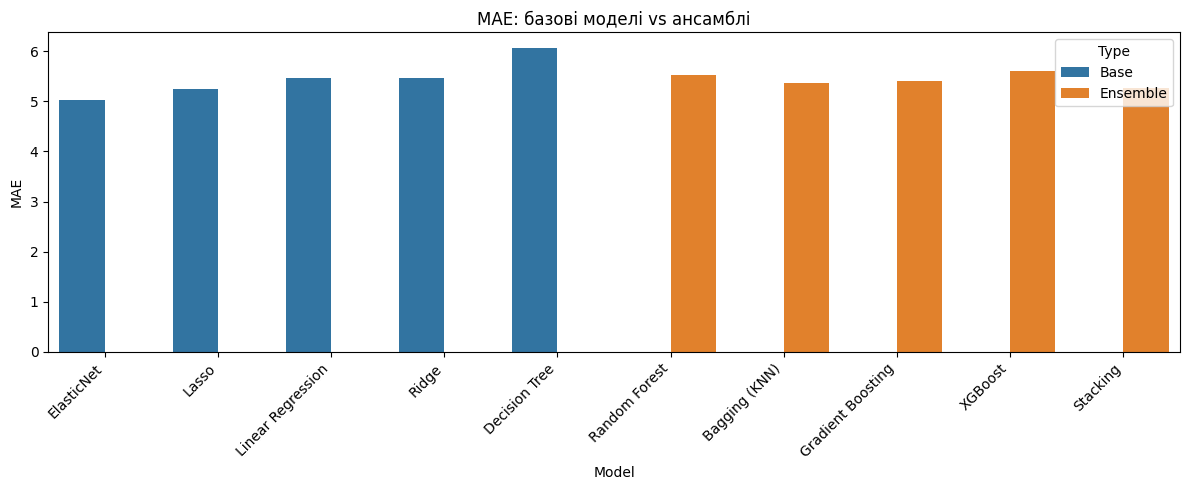

In [16]:
# Порівняння з базовими моделями
all_res = pd.concat([results_df.assign(Type="Base"), ensemble_results.assign(Type="Ensemble")])
sns.barplot(data=all_res, x="Model", y="MAE", hue="Type", dodge=True)
plt.xticks(rotation=45, ha="right")
plt.title("MAE: базові моделі vs ансамблі")
plt.tight_layout()
plt.show()

c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


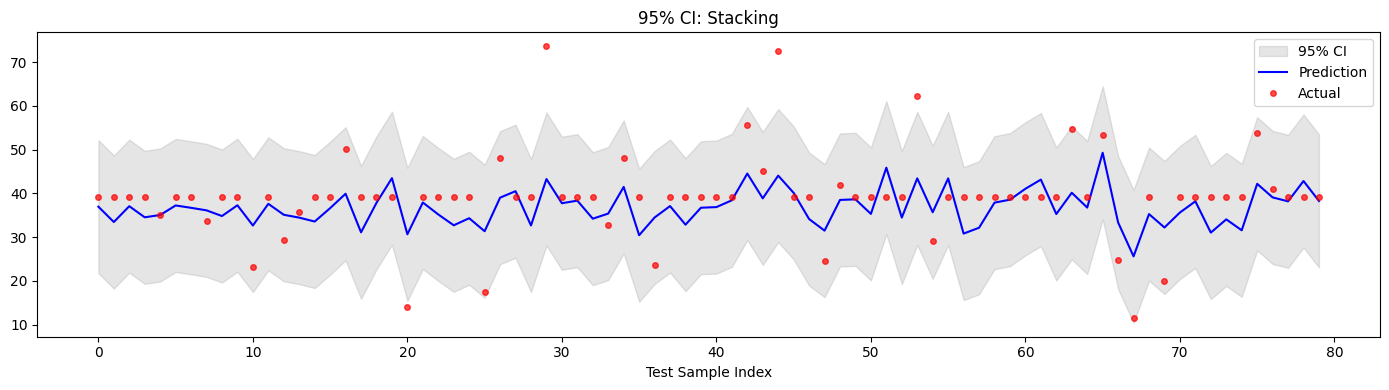

In [17]:
# Ймовірнісні межі для кращого ансамбля
best_ens = ensemble_results.loc[ensemble_results["MAE"].idxmin(), "Model"]
model, rmse_cv = ensemble_trained[best_ens]
y_pred = model.predict(X_test_transformed)
n_sample = min(80, len(y_test))
ci_plus, ci_minus = get_conf_int(y_pred, rmse_cv)
plt.figure(figsize=(14, 4))
plt.fill_between(range(n_sample), ci_minus[:n_sample], ci_plus[:n_sample], alpha=0.2, color="gray", label="95% CI")
plt.plot(y_pred[:n_sample], "b-", lw=1.5, label="Prediction")
y_act = np.asarray(pd.to_numeric(y_test, errors="coerce"), dtype=np.float64).ravel()[:n_sample]
y_act = np.nan_to_num(y_act, nan=np.nanmean(y_act))
plt.plot(range(n_sample), y_act, "ro", markersize=4, alpha=0.7, label="Actual")
plt.title(f"95% CI: {best_ens}")
plt.legend()
plt.xlabel("Test Sample Index")
plt.tight_layout()
plt.show()

<a id="discrete"></a>
## IV. Перехід від регресії до класифікації

### 1. Дискретизація цільової змінної (Equal-width binning)

In [18]:
def discretize_target(y_tr, y_te, n_bins=3):
    """Equal-width binning (KBinsDiscretizer strategy='uniform')"""
    y_tr = np.asarray(pd.to_numeric(y_tr, errors="coerce"), dtype=np.float64).ravel().reshape(-1, 1)
    y_te = np.asarray(pd.to_numeric(y_te, errors="coerce"), dtype=np.float64).ravel().reshape(-1, 1)
    fill = np.nanmean(y_tr)
    if np.isnan(fill):
        fill = 0.0
    y_tr = np.nan_to_num(y_tr, nan=fill)
    y_te = np.nan_to_num(y_te, nan=fill)
    disc = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="uniform")
    y_tr_disc = disc.fit_transform(y_tr).ravel().astype(int)
    y_te_disc = disc.transform(y_te).ravel().astype(int)
    return y_tr_disc, y_te_disc, disc

In [19]:
n_bins_1 = 3
y_train_cls1, y_test_cls1, disc1 = discretize_target(y_train, y_test, n_bins=n_bins_1)
print(f"Класи (n_bins={n_bins_1}):", np.unique(y_train_cls1))

Класи (n_bins=3): [0 1 2]


### 2. Навчання класифікаторів та оцінка метрик

In [20]:
clf_models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("XGBoost", XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")),
]

def eval_classifiers(models, X_tr, y_tr, X_te, y_te):
    res = []
    fitted = {}
    for name, m in models:
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        fitted[name] = m
        res.append({
            "Model": name,
            "Accuracy": accuracy_score(y_te, y_pred),
            "Precision": precision_score(y_te, y_pred, average="weighted", zero_division=0),
            "Recall": recall_score(y_te, y_pred, average="weighted", zero_division=0),
            "F1": f1_score(y_te, y_pred, average="weighted", zero_division=0),
        })
    return pd.DataFrame(res), fitted

In [21]:
cls_results_1, cls_fitted_1 = eval_classifiers(clf_models, X_train_transformed, y_train_cls1, X_test_transformed, y_test_cls1)
cls_results_1

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.9545,0.956071,0.9545,0.932769
1,Decision Tree,0.9385,0.932836,0.9385,0.935520
2,XGBoost,0.9455,0.928358,0.9455,0.935382


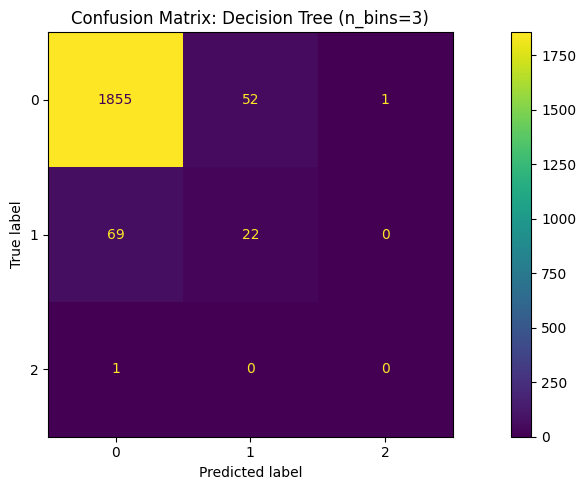

In [22]:
best_clf_1 = cls_results_1.loc[cls_results_1["F1"].idxmax(), "Model"]
y_pred_1 = cls_fitted_1[best_clf_1].predict(X_test_transformed)
ConfusionMatrixDisplay(confusion_matrix(y_test_cls1, y_pred_1), display_labels=np.unique(y_train_cls1)).plot()
plt.title(f"Confusion Matrix: {best_clf_1} (n_bins={n_bins_1})")
plt.tight_layout()
plt.show()

### 4. Інший крок дискретизації та порівняння

Повторюємо з n_bins=5

In [23]:
n_bins_2 = 5
y_train_cls2, y_test_cls2, disc2 = discretize_target(y_train, y_test, n_bins=n_bins_2)
cls_results_2, cls_fitted_2 = eval_classifiers(clf_models, X_train_transformed, y_train_cls2, X_test_transformed, y_test_cls2)
cls_results_2

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8220,0.834980,0.8220,0.743632
1,Decision Tree,0.7505,0.750543,0.7505,0.750461
2,XGBoost,0.8065,0.762782,0.8065,0.772302


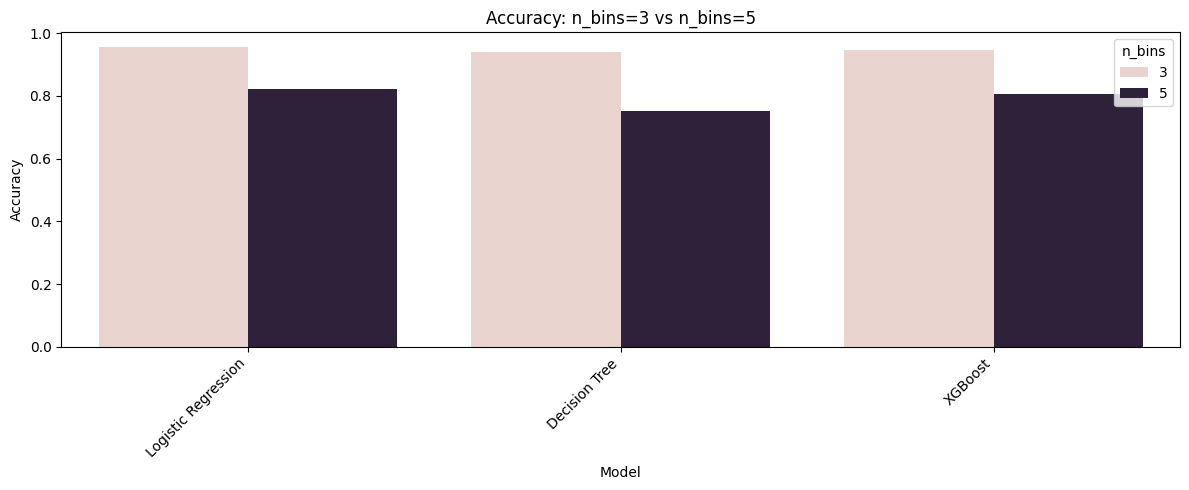

In [24]:
comp = pd.concat([
    cls_results_1.assign(n_bins=n_bins_1),
    cls_results_2.assign(n_bins=n_bins_2),
])
sns.barplot(data=comp, x="Model", y="Accuracy", hue="n_bins")
plt.xticks(rotation=45, ha="right")
plt.title("Accuracy: n_bins=3 vs n_bins=5")
plt.tight_layout()
plt.show()

<a id="probs"></a>
## V. Розподіл ймовірностей у класифікації

### 1. Розподіл ймовірностей передбачень (predict_proba)

In [25]:
y_proba_tree = cls_fitted_1["Decision Tree"].predict_proba(X_test_transformed)
y_proba_xgb = cls_fitted_1["XGBoost"].predict_proba(X_test_transformed)
y_proba_lr = cls_fitted_1["Logistic Regression"].predict_proba(X_test_transformed)

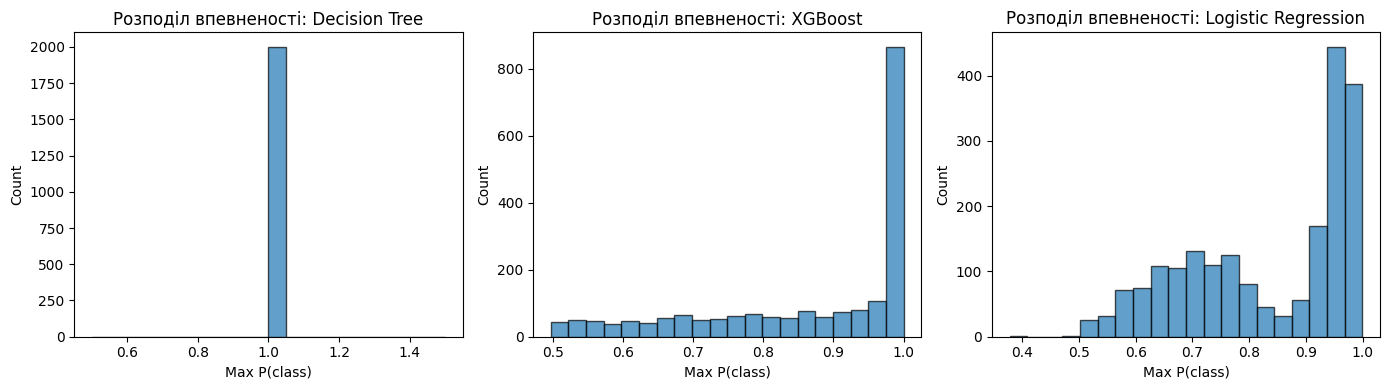

In [26]:
# Гістограма ймовірностей
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, proba) in zip(axes, [
    ("Decision Tree", y_proba_tree),
    ("XGBoost", y_proba_xgb),
    ("Logistic Regression", y_proba_lr),
]):
    max_proba = np.max(proba, axis=1)
    ax.hist(max_proba, bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(f"Розподіл впевненості: {name}")
    ax.set_xlabel("Max P(class)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 3. Overfitting vs Underfitting через розподіл ймовірностей

- **Overfitting**: модель дуже впевнена (ймовірності близькі до 0 або 1), гістограма зібрана по краях
- **Underfitting**: модель невпевнена (ймовірності розмазані), гістограма близько 1/n_classes

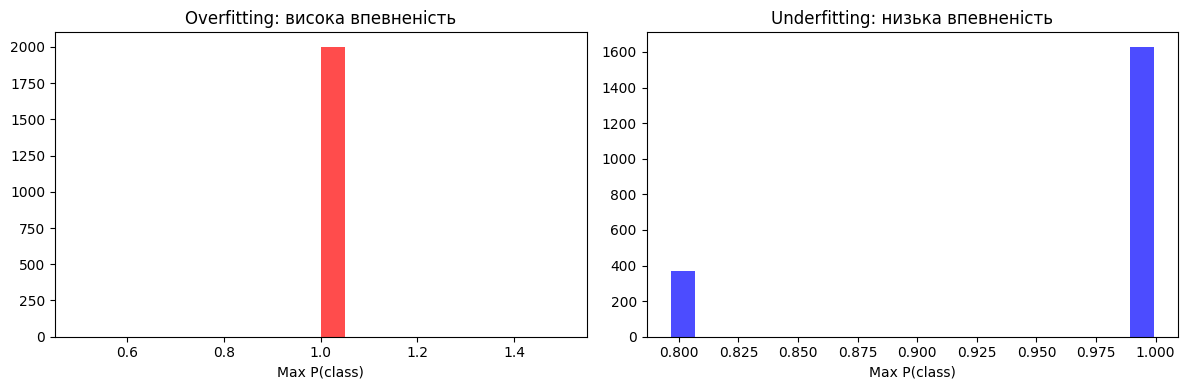

In [27]:
# Створюємо overfit та underfit моделі
dt_overfit = DecisionTreeClassifier(max_depth=50, min_samples_leaf=1, random_state=42)
dt_underfit = DecisionTreeClassifier(max_depth=1, random_state=42)
dt_overfit.fit(X_train_transformed, y_train_cls1)
dt_underfit.fit(X_train_transformed, y_train_cls1)

proba_over = dt_overfit.predict_proba(X_test_transformed)
proba_under = dt_underfit.predict_proba(X_test_transformed)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.max(proba_over, axis=1), bins=20, color="red", alpha=0.7, label="Overfitting (depth=50)")
axes[0].set_title("Overfitting: висока впевненість")
axes[0].set_xlabel("Max P(class)")
axes[1].hist(np.max(proba_under, axis=1), bins=20, color="blue", alpha=0.7, label="Underfitting (depth=1)")
axes[1].set_title("Underfitting: низька впевненість")
axes[1].set_xlabel("Max P(class)")
plt.tight_layout()
plt.show()

<a id="opt"></a>
## VI. Оптимізація класифікатора

### 1. Вибір кращого варіанту дискретизації

In [28]:
avg_f1_3 = cls_results_1["F1"].mean()
avg_f1_5 = cls_results_2["F1"].mean()
best_n_bins = n_bins_1 if avg_f1_3 >= avg_f1_5 else n_bins_2
print(f"n_bins=3: avg F1={avg_f1_3:.4f}, n_bins=5: avg F1={avg_f1_5:.4f}")
print(f"Обраний варіант: n_bins={best_n_bins}")

y_train_cls = y_train_cls1 if best_n_bins == n_bins_1 else y_train_cls2
y_test_cls = y_test_cls1 if best_n_bins == n_bins_1 else y_test_cls2

n_bins=3: avg F1=0.9346, n_bins=5: avg F1=0.7555
Обраний варіант: n_bins=3


### 2. Оптимізація гіперпараметрів (GridSearchCV)

Оптимізуємо Gradient Boosting - простір включає базові значення.

In [29]:
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
param_grid_clf = {
    "n_estimators": [50, 100],
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.1],
    "min_samples_split": [2, 5],
}
grid_clf = GridSearchCV(gb_clf, param_grid_clf, cv=3, scoring="f1_weighted", n_jobs=4, verbose=1)
grid_clf.fit(X_train_transformed, y_train_cls)
print("Best params:", grid_clf.best_params_)
print("Best F1 (CV):", grid_clf.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Python314\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Best params: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 (CV): 0.9484430649186625


In [ ]:
# Оцінка на тесті
y_pred_opt = grid_clf.predict(X_test_transformed)
print("Після оптимізації: Accuracy={:.4f}, Precision={:.4f}, Recall={:.4f}, F1={:.4f}".format(
    accuracy_score(y_test_cls, y_pred_opt),
    precision_score(y_test_cls, y_pred_opt, average="weighted", zero_division=0),
    recall_score(y_test_cls, y_pred_opt, average="weighted", zero_division=0),
    f1_score(y_test_cls, y_pred_opt, average="weighted", zero_division=0),
))  

Після оптимізації: Accuracy=0.9525, Precision=0.9338, Recall=0.9525, F1=0.9374


<a id="metrics"></a>
## VII. Перетворення метрик між регресією та класифікацією

### 1. Формули: MAE регресії ↔ Accuracy класифікації

Наближення: Accuracy ≈ 1 - MAE / (max(y) - min(y)) для нормалізованої цільової змінної.
Зворотне: MAE ≈ (1 - Accuracy) * (max(y) - min(y)) (грубе наближення).

In [31]:
# Отримуємо прогнози регресійної моделі та класифікації
def _to_numeric_safe(ser):
    s = ser.astype(str).str.replace(r'\.(?=.*\.)', '', regex=True)  
    return np.asarray(pd.to_numeric(s, errors="coerce"), dtype=np.float64)
y_test_num = _to_numeric_safe(y_test)
y_train_num = _to_numeric_safe(y_train)
y_test_num = np.nan_to_num(y_test_num, nan=np.nanmean(y_test_num))
y_train_num = np.nan_to_num(y_train_num, nan=np.nanmean(y_train_num))
best_reg_model = ensemble_trained[ensemble_results.loc[ensemble_results["MAE"].idxmin(), "Model"]][0]
y_hat_reg = best_reg_model.predict(X_test_transformed)
y_hat_class = grid_clf.predict(X_test_transformed)  

reg_mae = mean_absolute_error(y_test_num, y_hat_reg)
cls_acc = accuracy_score(y_test_cls, y_hat_class)
y_range = float(np.max(y_train_num) - np.min(y_train_num))

mae_norm = reg_mae / y_range if y_range > 0 else 0
acc_from_mae = max(0, 1 - mae_norm)
print(f"Регресія MAE: {reg_mae:.4f}, range(y): {y_range:.4f}")
print(f"Accuracy з MAE (формула): {acc_from_mae:.4f}")
print(f"Фактична Accuracy класифікації: {cls_acc:.4f}")

Регресія MAE: 2512056.7097, range(y): 9983327.5330
Accuracy з MAE (формула): 0.7484
Фактична Accuracy класифікації: 0.9525


c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
c:\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


### 2. Дискретизація прогнозів регресії (KBinsDiscretizer) та порівняння з фактичними класами

In [32]:
disc_metrics = KBinsDiscretizer(n_bins=best_n_bins, encode="ordinal", strategy="uniform")
disc_metrics.fit(y_train_num.reshape(-1, 1))

y_test_disc = disc_metrics.transform(y_test_num.reshape(-1, 1)).ravel().astype(int)
y_hat_reg_disc = disc_metrics.transform(y_hat_reg.reshape(-1, 1)).ravel().astype(int)

acc_discretized = accuracy_score(y_test_disc, y_hat_reg_disc)
print(f"Точність (Accuracy) дискретизованих прогнозів регресії: {acc_discretized:.4f}")
print(f"Точність класифікатора: {cls_acc:.4f}")

Точність (Accuracy) дискретизованих прогнозів регресії: 0.6475
Точність класифікатора: 0.9525


### 3. MAE через дискретизовані прогнозування (середні значення для класів)

In [33]:
# Середнє значення y для кожного класу 
y_train_disc = disc_metrics.transform(y_train_num.reshape(-1, 1)).ravel().astype(int)
class_means = {}
for k in range(best_n_bins):
    mask = y_train_disc == k
    class_means[k] = y_train_num[mask].mean() if mask.any() else np.mean(y_train_num)

# Прогноз класифікатора перетворюємо в неперервні значення
y_hat_class_continuous = np.array([class_means[c] for c in y_hat_class])
mae_from_classes = mean_absolute_error(y_test_num, y_hat_class_continuous)

# Регресія - дискретизуємо - середнє класу
y_hat_reg_to_cont = np.array([class_means[c] for c in y_hat_reg_disc])
mae_reg_disc = mean_absolute_error(y_test_num, y_hat_reg_to_cont)

print(f"MAE регресії (оригінал): {reg_mae:.4f}")
print(f"MAE через дискретизовані прогнози регресії: {mae_reg_disc:.4f}")
print(f"MAE через прогнози класифікатора (середнє класу): {mae_from_classes:.4f}")

MAE регресії (оригінал): 2512056.7097
MAE через дискретизовані прогнози регресії: 2042325.3200
MAE через прогнози класифікатора (середнє класу): 2045258.0576


Висновок: кращий результат дала регресія через ElasticNetб stacking